In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("diyer22/retail-product-checkout-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'retail-product-checkout-dataset' dataset.
Path to dataset files: /kaggle/input/retail-product-checkout-dataset


In [2]:
import json
path = "/kaggle/input/retail-product-checkout-dataset/instances_train2019.json"

with open(path, 'r') as f:
    data = json.load(f)

print(data.keys())

dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations'])


In [3]:
import json

path = "/kaggle/input/retail-product-checkout-dataset/instances_train2019.json"

with open(path, 'r') as f:
    data = json.load(f)

categories = data['categories']

for c in categories[0:10]:
    print(c)

{'supercategory': 'puffed_food', 'id': 1, 'name': '1_puffed_food'}
{'supercategory': 'puffed_food', 'id': 2, 'name': '2_puffed_food'}
{'supercategory': 'puffed_food', 'id': 3, 'name': '3_puffed_food'}
{'supercategory': 'puffed_food', 'id': 4, 'name': '4_puffed_food'}
{'supercategory': 'puffed_food', 'id': 5, 'name': '5_puffed_food'}
{'supercategory': 'puffed_food', 'id': 6, 'name': '6_puffed_food'}
{'supercategory': 'puffed_food', 'id': 7, 'name': '7_puffed_food'}
{'supercategory': 'puffed_food', 'id': 8, 'name': '8_puffed_food'}
{'supercategory': 'puffed_food', 'id': 9, 'name': '9_puffed_food'}
{'supercategory': 'puffed_food', 'id': 10, 'name': '10_puffed_food'}


In [4]:
import os
import json
import random
import shutil
from tqdm import tqdm
from PIL import Image

# Paths
base_path = "/kaggle/input/retail-product-checkout-dataset"

json_path = os.path.join(base_path, "instances_train2019.json")

images_dir = os.path.join(base_path, "train2019")

output_dir = "/content/dataset"

img_train_dir = os.path.join(output_dir, "images/train")
img_val_dir   = os.path.join(output_dir, "images/val")
lbl_train_dir = os.path.join(output_dir, "labels/train")
lbl_val_dir   = os.path.join(output_dir, "labels/val")

for d in [img_train_dir, img_val_dir, lbl_train_dir, lbl_val_dir]:
    os.makedirs(d, exist_ok=True)

# Load COCO
with open(json_path, 'r') as f:
    data = json.load(f)

images = data['images']
annotations = data['annotations']

# ---- STEP 1: map image_id -> file_name AND real (width, height) ----
img_map = {img['id']: img['file_name'] for img in images}
# COCO 'images' entries normally already carry width/height - use them
# directly instead of opening every file; fall back to PIL if missing.
img_size_map = {img['id']: (img.get('width'), img.get('height')) for img in images}

# ---- STEP 2: group annotations by image ----
ann_map = {}
for ann in annotations:
    img_id = ann['image_id']
    ann_map.setdefault(img_id, []).append(ann)

# ---- STEP 3: sample images (5k-10k) ----
all_ids = list(img_map.keys())
sample_ids = random.sample(all_ids, 8000)  # adjust later

# ---- STEP 4: split ----
split = int(0.8 * len(sample_ids))
train_ids = sample_ids[:split]
val_ids = sample_ids[split:]

# ---- STEP 5: convert COCO -> YOLO ----
def convert_bbox(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = box[0] + box[2] / 2.0
    y = box[1] + box[3] / 2.0
    w = box[2]
    h = box[3]
    return (x * dw, y * dh, w * dw, h * dh)

def process(ids, img_out, lbl_out):
    for img_id in tqdm(ids):
        if img_id not in img_map:
            continue

        file_name = img_map[img_id]
        src_img = os.path.join(images_dir, file_name)

        if not os.path.exists(src_img):
            continue

        # copy image
        shutil.copy(src_img, os.path.join(img_out, file_name))

        # get annotations
        anns = ann_map.get(img_id, [])

        # ---- FIX: use each image's REAL width/height, not a 640x640 placeholder ----
        w, h = img_size_map.get(img_id, (None, None))
        if not w or not h:
            with Image.open(src_img) as im:
                w, h = im.size

        label_file = file_name.replace(".jpg", ".txt")

        with open(os.path.join(lbl_out, label_file), "w") as f:
            for ann in anns:
                bbox = ann['bbox']

                # SINGLE CLASS = 0 (product)
                x, y, bw, bh = convert_bbox((w, h), bbox)

                f.write(f"0 {x} {y} {bw} {bh}\n")

# ---- RUN ----
process(train_ids, img_train_dir, lbl_train_dir)
process(val_ids, img_val_dir, lbl_val_dir)


100%|██████████| 1600/1600 [00:09<00:00, 172.27it/s]


In [5]:
from PIL import Image
import os
import random

img_dir = "/content/dataset/images/train"

files = random.sample(os.listdir(img_dir), 10)

for f in files:
    img_path = os.path.join(img_dir, f)
    img = Image.open(img_path)
    print(f, img.size)

6907992100272_camera3-32.jpg (2592, 1944)
6901236378823-back_camera2-3.jpg (2592, 1944)
6901236378823_camera0-10.jpg (2592, 1944)
6928804011173_camera0-16.jpg (2592, 1944)
6907777800151-back_camera3-36.jpg (2592, 1944)
6920152439005_camera0-9.jpg (2592, 1944)
6933631504811-back_camera3-40.jpg (2592, 1944)
6907777830523-back_camera3-39.jpg (2592, 1944)
6914068016535-back_camera3-36.jpg (2592, 1944)
6953787800124_camera2-12.jpg (2592, 1944)


In [6]:
import os

label_dir = "/content/dataset/labels/train"

empty = []

for f in os.listdir(label_dir):
    path = os.path.join(label_dir, f)
    if os.path.getsize(path) == 0:
        empty.append(f)

print("Empty label files:", len(empty))

Empty label files: 0


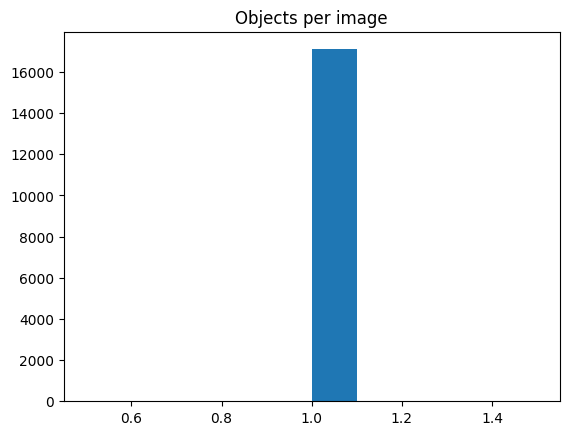

In [7]:
import matplotlib.pyplot as plt

label_dir = "/content/dataset/labels/train"

counts = []

for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as file:
        lines = file.readlines()
        counts.append(len(lines))

plt.hist(counts, bins=10)
plt.title("Objects per image")
plt.show()

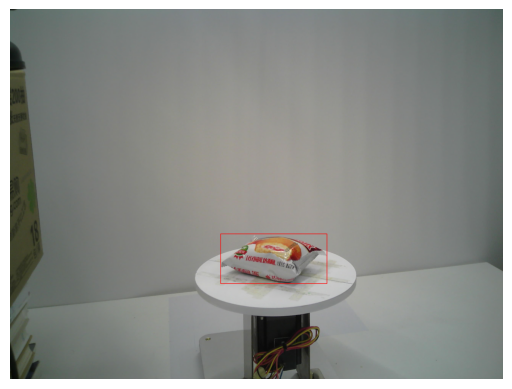

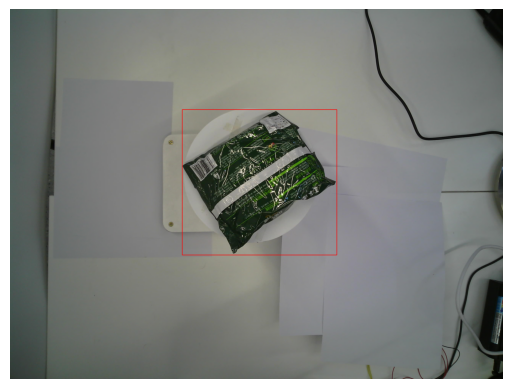

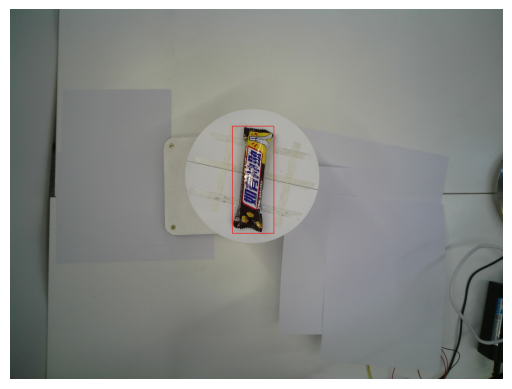

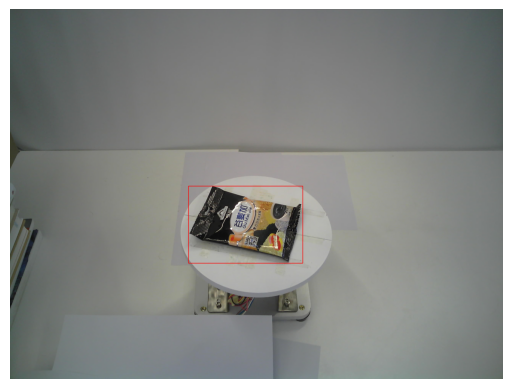

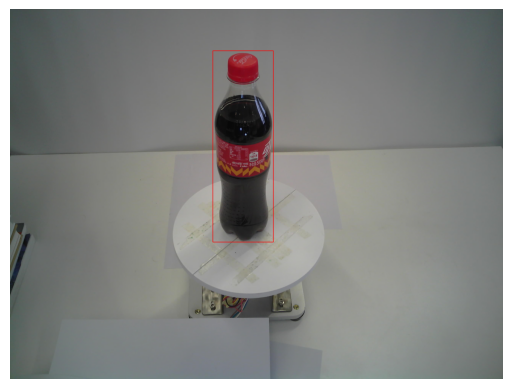

In [8]:
import cv2
import matplotlib.pyplot as plt
import random

img_dir = "/content/dataset/images/train"
label_dir = "/content/dataset/labels/train"

files = random.sample(os.listdir(img_dir), 5)

for f in files:
    img_path = os.path.join(img_dir, f)
    label_path = os.path.join(label_dir, f.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as file:
            for line in file:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [9]:
import os

label_dir = "/content/dataset/labels/train"

counts = []

for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as file:
        lines = file.readlines()
        counts.append(len(lines))

print("Min objects:", min(counts))
print("Max objects:", max(counts))
print("Avg objects:", sum(counts)/len(counts))

Min objects: 1
Max objects: 1
Avg objects: 1.0


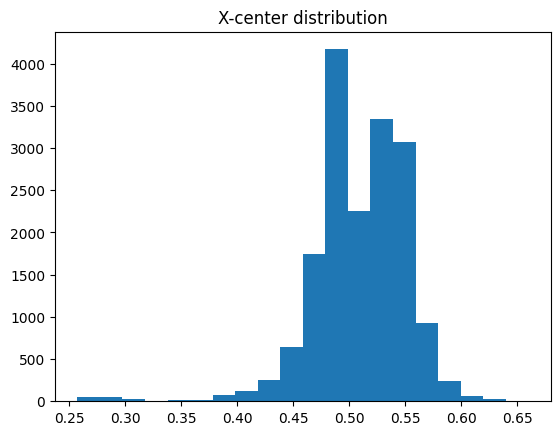

In [10]:
import numpy as np

x_centers = []

label_dir = "/content/dataset/labels/train"

for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as file:
        for line in file:
            cls, x, y, w, h = map(float, line.split())
            x_centers.append(x)

plt.hist(x_centers, bins=20)
plt.title("X-center distribution")
plt.show()

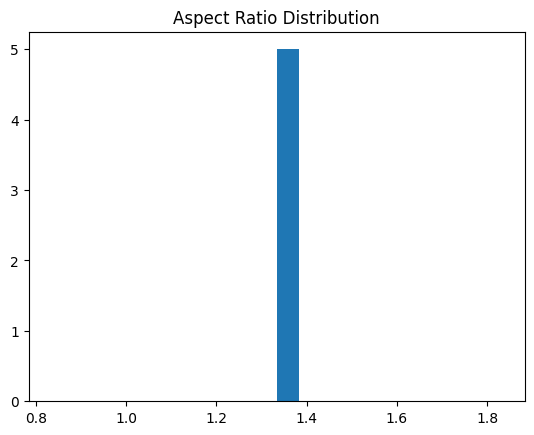

In [11]:
ratios = []

for f in files:
    img = Image.open(os.path.join(img_dir, f))
    w, h = img.size
    ratios.append(w / h)

plt.hist(ratios, bins=20)
plt.title("Aspect Ratio Distribution")
plt.show()

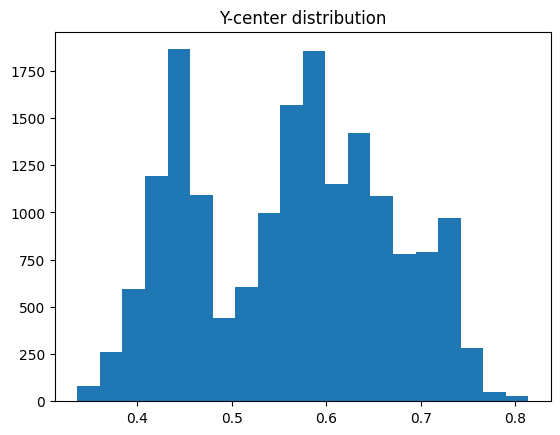

In [12]:
y_centers = []

for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as file:
        for line in file:
            cls, x, y, w, h = map(float, line.split())
            y_centers.append(y)

plt.hist(y_centers, bins=20)
plt.title("Y-center distribution")
plt.show()

In [13]:
!pip install albumentations

In [14]:
import albumentations as A
import cv2

aspect_ratio_aug = A.Compose([
    A.LongestMaxSize(max_size=640),

    A.PadIfNeeded(
        min_height=640,
        min_width=640,
        border_mode=cv2.BORDER_CONSTANT
    ),

    A.RandomScale(scale_limit=0.3, p=0.5),
    A.Resize(640, 640)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

In [15]:
camera_sim = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.2,
        rotate_limit=25,
        p=0.7
    ),

    A.Perspective(
        scale=(0.05, 0.1),
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.4),

    A.GaussianBlur(p=0.2)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [16]:
import random

def multi_camera_aug(image, bboxes, class_labels):

    mode = random.choice(["phone", "cctv", "overhead"])

    if mode == "phone":
        transform = A.Compose([
            A.Rotate(limit=30, p=0.7),
            A.ColorJitter(p=0.5),
            A.RandomShadow(p=0.3)
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    elif mode == "cctv":
        transform = A.Compose([
            A.GaussNoise(p=0.6),
            A.MotionBlur(p=0.4),
            A.RandomBrightnessContrast(0.2, 0.3, p=0.7)
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    else:  # overhead
        transform = A.Compose([
            A.Perspective(scale=(0.08, 0.12), p=0.7),
            A.Rotate(limit=90, p=0.5),
            A.Resize(640, 640)
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    return transform(image=image, bboxes=bboxes, class_labels=class_labels)

In [17]:
import cv2
import os

def load_object(img_path, label_path):
    img = cv2.imread(img_path)
    h, w, _ = img.shape

    objects = []

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.split())

            # YOLO → pixel coords
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            crop = img[y1:y2, x1:x2]
            objects.append(crop)

    return objects

In [18]:
import numpy as np

def create_canvas():
    return np.ones((640, 640, 3), dtype=np.uint8) * 255

In [19]:
import random
import numpy as np

def iou_xywh_frac(b1, b2):
    """Fraction of box b1's area that is covered by box b2.
    b1, b2 are normalized [cx, cy, w, h]."""
    def to_xyxy(b):
        cx, cy, w, h = b
        return cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2

    x1a, y1a, x2a, y2a = to_xyxy(b1)
    x1b, y1b, x2b, y2b = to_xyxy(b2)

    inter_w = max(0, min(x2a, x2b) - max(x1a, x1b))
    inter_h = max(0, min(y2a, y2b) - max(y1a, y1b))
    inter = inter_w * inter_h

    area_a = (x2a - x1a) * (y2a - y1a)
    if area_a <= 0:
        return 0
    return inter / area_a


def augment_object(obj):
    """Run one of the camera-style augmentations on a single cropped object."""
    aug = multi_camera_aug(
        image=obj,
        bboxes=[[0.5, 0.5, 1.0, 1.0]],  # whole-crop box in YOLO format (center, full size)
        class_labels=[0]
    )
    return aug['image']


def paste_object(canvas, obj, occlusion_thresh=0.6):
    """Augment, resize, and blend one object onto the canvas.
    Returns (canvas, bbox) where bbox is None if the object couldn't be placed."""
    h, w, _ = canvas.shape

    obj = augment_object(obj)

    scale = random.uniform(0.3, 0.8)
    oh, ow = obj.shape[:2]
    new_w, new_h = max(1, int(ow * scale)), max(1, int(oh * scale))
    obj = cv2.resize(obj, (new_w, new_h))

    oh, ow = obj.shape[:2]
    if ow >= w or oh >= h:
        return canvas, None

    x = random.randint(0, w - ow)
    y = random.randint(0, h - oh)

    # ---- blend instead of a hard paste, to avoid a visible cut-paste seam ----
    mask = 255 * np.ones(obj.shape, obj.dtype)
    center = (x + ow // 2, y + oh // 2)
    try:
        canvas = cv2.seamlessClone(obj, canvas, mask, center, cv2.NORMAL_CLONE)
    except cv2.error:
        # seamlessClone can fail on degenerate/edge cases - fall back to hard paste
        canvas[y:y + oh, x:x + ow] = obj

    cx = (x + ow / 2) / w
    cy = (y + oh / 2) / h
    bw = ow / w
    bh = oh / h

    return canvas, [0, cx, cy, bw, bh]


def place_objects(canvas, object_list, max_objects=5, occlusion_thresh=0.6):

    bboxes = []
    num_objects = random.randint(2, max_objects)

    for _ in range(num_objects):
        obj = random.choice(object_list)
        canvas, new_box = paste_object(canvas, obj, occlusion_thresh)
        if new_box is None:
            continue

        # ---- occlusion handling: drop earlier boxes that the new object now
        # covers past the threshold, since they're no longer reliably visible ----
        bboxes = [
            old_box for old_box in bboxes
            if iou_xywh_frac(old_box[1:], new_box[1:]) < occlusion_thresh
        ]
        bboxes.append(new_box)

    return canvas, bboxes


In [20]:
def place_with_overlap(canvas, object_list, occlusion_thresh=0.6):

    canvas, bboxes = place_objects(canvas, object_list, occlusion_thresh=occlusion_thresh)

    # force one more object ON TOP of the others, simulating a partially hidden item
    if random.random() < 0.7:
        obj = random.choice(object_list)
        canvas, new_box = paste_object(canvas, obj, occlusion_thresh)
        if new_box is not None:
            bboxes = [
                old_box for old_box in bboxes
                if iou_xywh_frac(old_box[1:], new_box[1:]) < occlusion_thresh
            ]
            bboxes.append(new_box)

    return canvas, bboxes


In [21]:
def save_sample(img, bboxes, img_path, label_path):

    cv2.imwrite(img_path, img)

    with open(label_path, "w") as f:
        for box in bboxes:
            f.write(" ".join(map(str, box)) + "\n")

In [22]:
import random

MAX_OBJ_DIM = 400      # cap each stored crop's longer side (px) - final pasted
                        # size is scaled down anyway, so this loses no visible detail
MAX_POOL_SIZE = 3000    # cap total objects kept in RAM - plenty of diversity,
                        # no need to hold every single crop from the dataset

def resize_cap(img, max_dim):
    h, w = img.shape[:2]
    scale = max_dim / max(h, w)
    if scale < 1.0:
        img = cv2.resize(img, (max(1, int(w * scale)), max(1, int(h * scale))))
    return img

object_pool = []

img_names = os.listdir('/content/dataset/images/train')
random.shuffle(img_names)  # so an early cutoff still gives a representative sample

for img_name in img_names:

    if len(object_pool) >= MAX_POOL_SIZE:
        break

    img_path = os.path.join(img_dir, img_name)

    name = os.path.splitext(img_name)[0]
    label_path = os.path.join(label_dir, name + ".txt")

    if not os.path.exists(label_path):
        continue

    objects = load_object(img_path, label_path)

    for obj in objects:
        if obj is None:
            continue
        if obj.size == 0:
            continue
        if obj.shape[0] < 5 or obj.shape[1] < 5:
            continue

        obj = resize_cap(obj, MAX_OBJ_DIM)
        object_pool.append(obj)

        if len(object_pool) >= MAX_POOL_SIZE:
            break

print("Total objects:", len(object_pool))


Total objects: 3000


In [23]:
import os
import random
from tqdm import tqdm

synth_base = "/content/synth_dataset"
synth_img_train = os.path.join(synth_base, "images/train")
synth_img_val   = os.path.join(synth_base, "images/val")
synth_lbl_train = os.path.join(synth_base, "labels/train")
synth_lbl_val   = os.path.join(synth_base, "labels/val")

for d in [synth_img_train, synth_img_val, synth_lbl_train, synth_lbl_val]:
    os.makedirs(d, exist_ok=True)

NUM_TRAIN = 2000
NUM_VAL = 400

def generate_split(n, img_out, lbl_out, prefix):
    for i in tqdm(range(n)):
        canvas = create_canvas()

        # mix plain multi-object placement with the forced-overlap variant
        if random.random() < 0.5:
            canvas, bboxes = place_objects(canvas, object_pool, max_objects=5)
        else:
            canvas, bboxes = place_with_overlap(canvas, object_pool)

        if not bboxes:
            continue

        img_path = os.path.join(img_out, f"{prefix}_{i:05d}.jpg")
        label_path = os.path.join(lbl_out, f"{prefix}_{i:05d}.txt")
        save_sample(canvas, bboxes, img_path, label_path)

generate_split(NUM_TRAIN, synth_img_train, synth_lbl_train, "train")
generate_split(NUM_VAL, synth_img_val, synth_lbl_val, "val")

print("train images:", len(os.listdir(synth_img_train)))
print("val images:", len(os.listdir(synth_img_val)))

  0%|          | 0/2000 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
100%|██████████| 400/400 [01:33<00:00,  4.27it/s]

train images: 2000
val images: 400


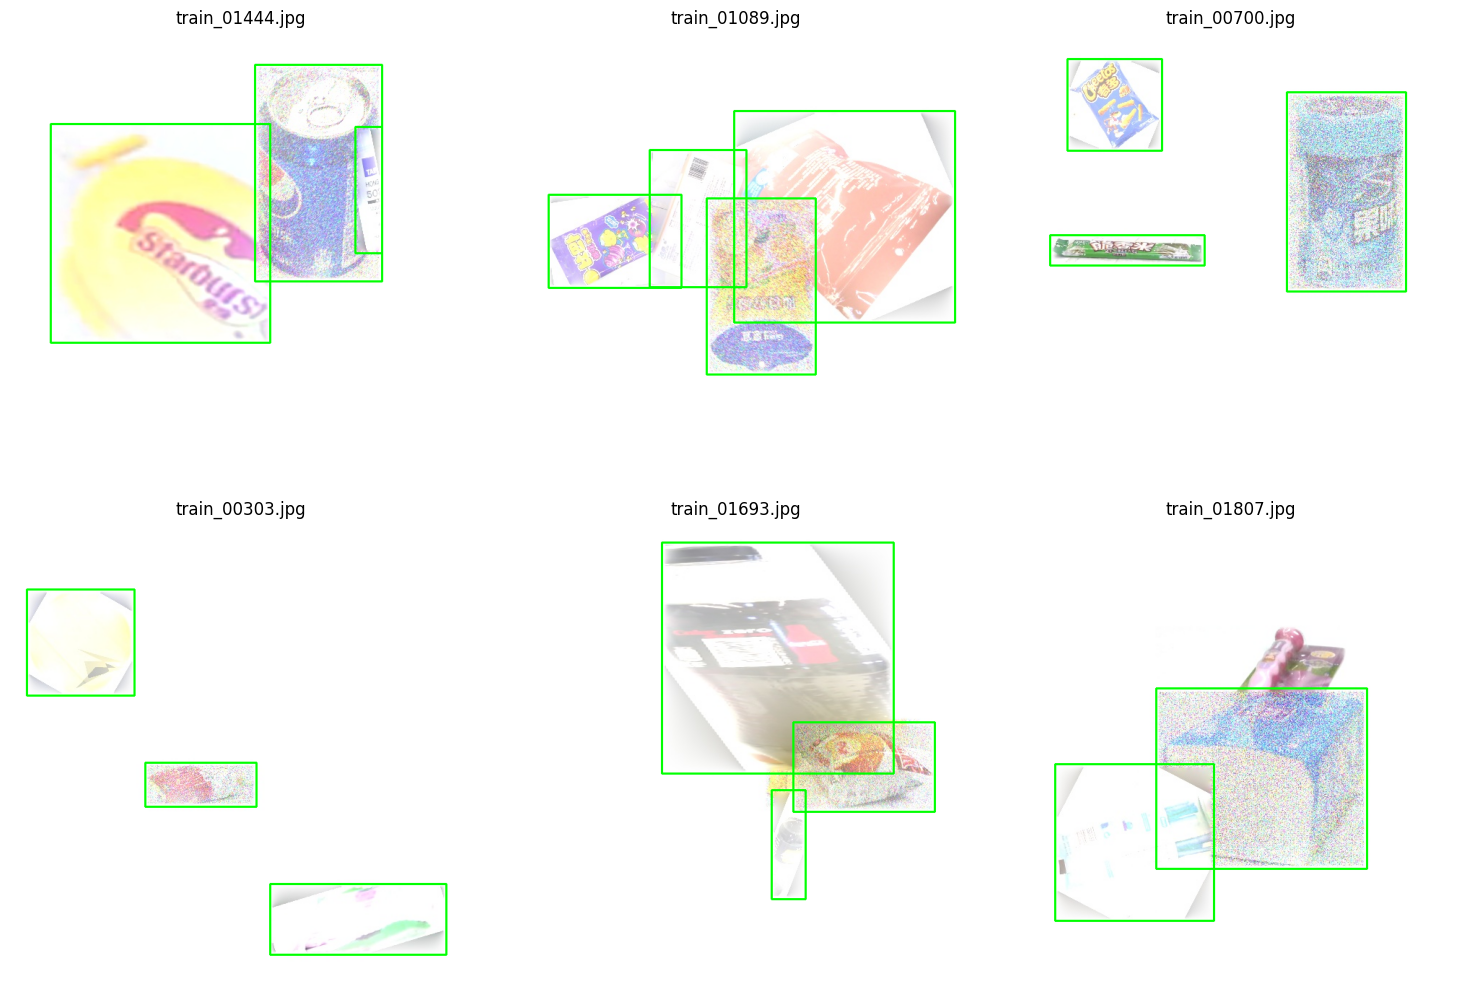

In [24]:
import matplotlib.pyplot as plt
import cv2
import random

sample_files = random.sample(os.listdir(synth_img_train), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, fname in zip(axes.flatten(), sample_files):
    img_path = os.path.join(synth_img_train, fname)
    label_path = os.path.join(synth_lbl_train, os.path.splitext(fname)[0] + ".txt")

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fname)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
data_yaml = f"""
path: {synth_base}
train: images/train
val: images/val

nc: 1
names: ['product']
"""

yaml_path = os.path.join(synth_base, "data.yaml")
with open(yaml_path, "w") as f:
    f.write(data_yaml)

print(data_yaml)
print("Saved to:", yaml_path)


path: /content/synth_dataset
train: images/train
val: images/val

nc: 1
names: ['product']

Saved to: /content/synth_dataset/data.yaml


In [ ]:
!pip install -q ultralytics

from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # small model for a fast first pass

results = model.train(
    data=yaml_path,
    epochs=10,        # smoke test - raise this once the pipeline is confirmed to work
    imgsz=640,
    batch=16,
    project="/content/runs",
    name="product_detector_smoketest"
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=F

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/product_detector_smoketest/weights/best.pt")

# metrics on your synthetic val set
metrics = model.val(data=yaml_path)
print(metrics.box.map)     # mAP50-95
print(metrics.box.map50)   # mAP50

In [ ]:
import glob

real_test_imgs = glob.glob("/kaggle/input/retail-product-checkout-dataset/val2019/*.jpg")[:10]

results = model.predict(real_test_imgs, conf=0.25, save=True)


In [ ]:
import cv2
from ultralytics import YOLO

MODEL_PATH = "best.pt"       # your trained weights
SOURCE = 0                    # 0 = webcam, or a video file path / RTSP URL

model = YOLO(MODEL_PATH)

seen_ids = set()
item_count = 0

# model.track() handles camera capture + detection + tracking in one loop
results_gen = model.track(
    source=SOURCE,
    tracker="bytetrack.yaml",
    persist=True,
    stream=True,     # yields results frame-by-frame instead of loading everything into memory
    conf=0.3,
    verbose=False
)

for result in results_gen:
    frame = result.orig_img

    # ---- ALERTS: log/count only new track IDs ----
    if result.boxes.id is not None:
        ids = result.boxes.id.int().tolist()
        for track_id in ids:
            if track_id not in seen_ids:
                seen_ids.add(track_id)
                item_count += 1
                print(f"[LOG] New item seen - ID {track_id} | total count: {item_count}")

    # ---- RENDER ----
    annotated = result.plot()   # draws boxes + track IDs
    cv2.putText(
        annotated, f"Total items: {item_count}",
        (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2
    )

    # ---- SCREEN ----
    cv2.imshow("Product Counter", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cv2.destroyAllWindows()